In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
from sklearn.preprocessing import LabelEncoder

import zglitchfunc as gf

In [7]:
clust = 'gspy'
run = 'O3b'

arq_name = f'{clust}{run}'

In [8]:
# base_data = '/home/esanches/Projetos/tSNE/Virgo/'
repository = f'C:/Users/erick/Downloads/JupyterNotebook/github/tSNE_analysis/zrepository/{clust}/{run}/'

# filterr = True

## tSNE plots for O3a

### Perplexity and dt configurations

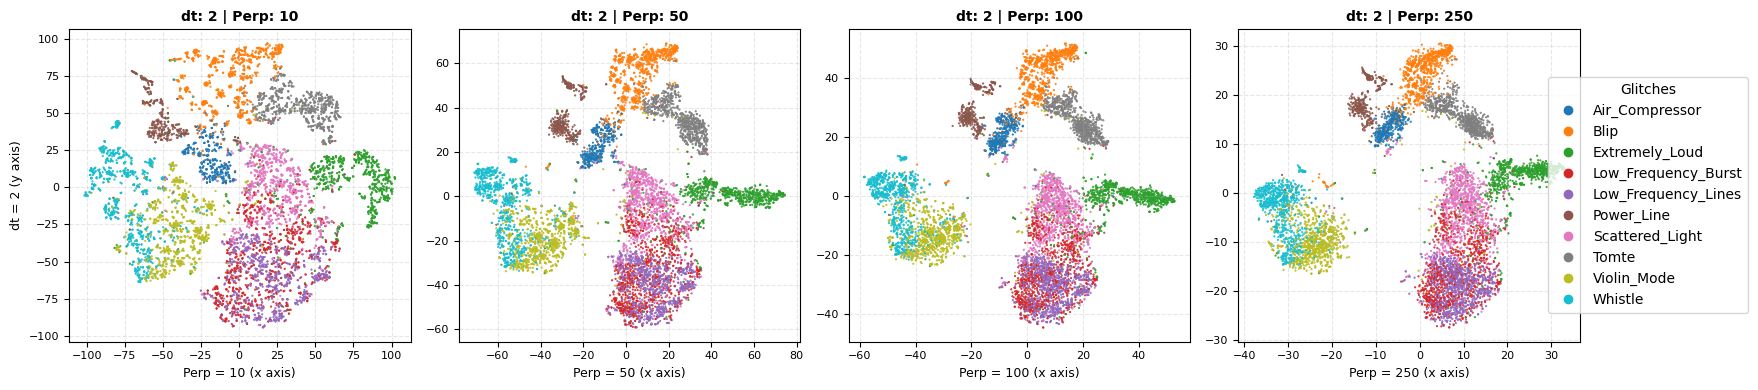

In [8]:
dt = 2
lista_perp = [10, 50, 100, 250]

fig, axs = plt.subplots(1, len(lista_perp), figsize=(4*len(lista_perp), 4))
# fig, axs = plt.subplots(len(lista_dt), len(lista_perp), figsize=(12, 9), sharex=False, sharey=False)

le = LabelEncoder()

final_vecs = np.load(f"{repository}vecs_{arq_name}_dt{str(dt)}.npy")
final_labs = np.load(f"{repository}labs_{arq_name}_dt{str(dt)}.npy")
labels = le.fit_transform(final_labs.ravel())

for j, perp in enumerate(lista_perp):
    
    tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=perp, 
                learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(final_vecs)
    
    ax = axs[j]
    sc = ax.scatter(proj[:, 0], proj[:, 1], s=0.3, c=labels, cmap="tab10")
    ax.set_title(f"dt: {dt} | Perp: {perp}", fontsize=10, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    if j == 0:
        ax.set_ylabel(f"dt = {dt} (y axis)", fontsize=9)
        
    ax.set_xlabel(f"Perp = {perp} (x axis)", fontsize=9)

plt.tight_layout()
# plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.06, right=0.82, top=0.96, bottom=0.06)
fig.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center right', bbox_to_anchor=(1.1, 0.5))
plt.show()

One of the best configurations is when dt=2 and perplexity=100.

In [9]:
dt, perp = 2, 100

In [10]:
final_vecs = np.load(f"{repository}vecs_{arq_name}_dt{str(dt)}.npy")
final_labs = np.load(f"{repository}labs_{arq_name}_dt{str(dt)}.npy")

le = LabelEncoder()
labels = le.fit_transform(final_labs.ravel())

tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=perp, 
            learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
proj = tsne.fit_transform(final_vecs)

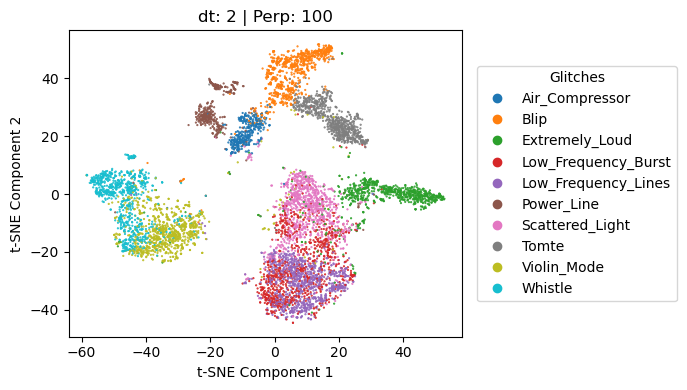

In [11]:
plt.figure(figsize=(7, 4))

sc = plt.scatter(proj[:, 0], proj[:, 1], s=0.3, c=labels, cmap="tab10")

plt.title(f"dt: {dt} | Perp: {perp}", fontsize=12)
plt.xlabel("t-SNE Component 1", fontsize=10)
plt.ylabel("t-SNE Component 2", fontsize=10)

plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), 
          title="Glitches", loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

### Seasonality

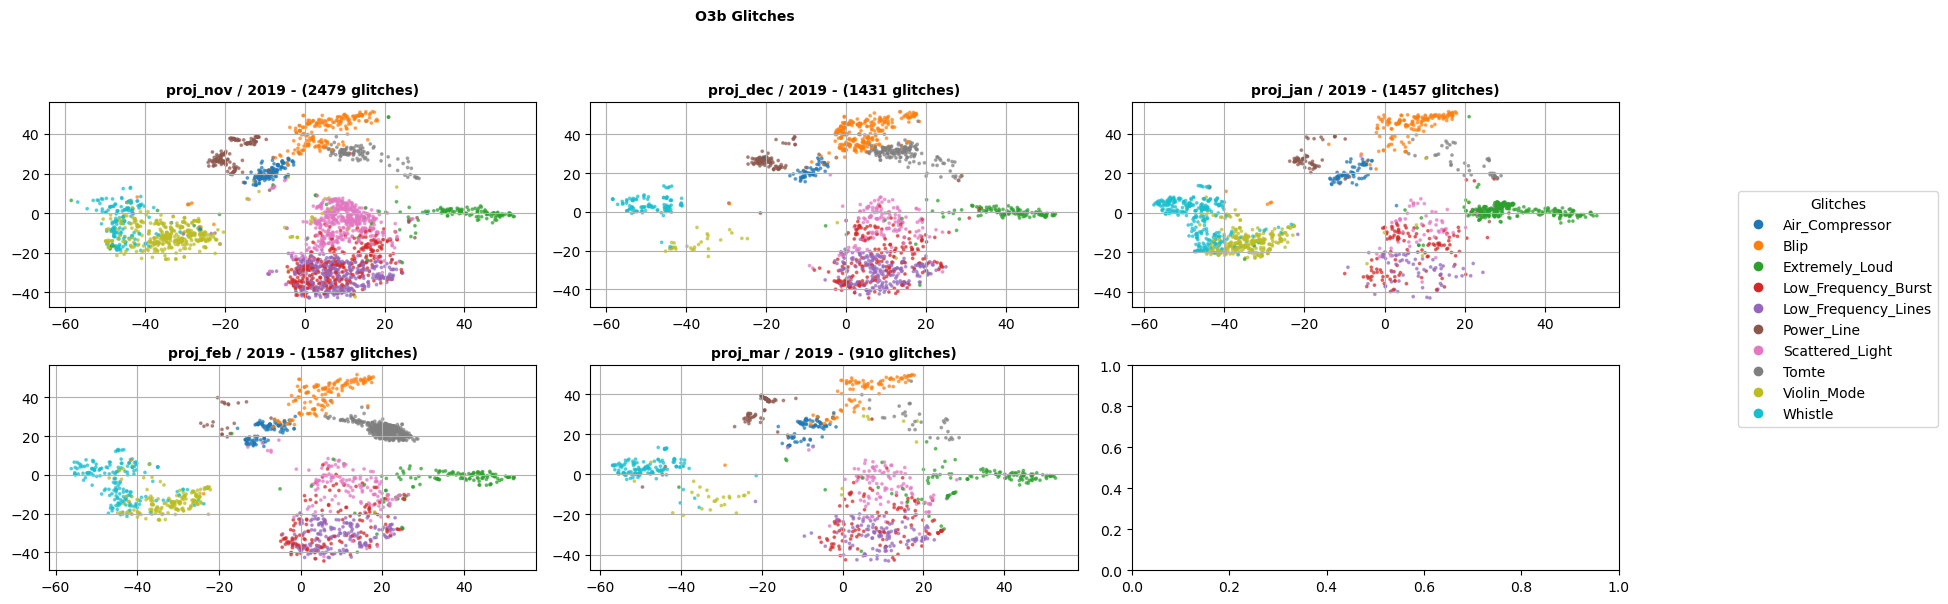

In [5]:
o3b_intervals = {
    'Nov': (1256655618, 1259247618),  # 01/Nov/2019 15:00 to 01/Dez/2019 15:00
    'Dec': (1259247618, 1261926018),  # 01/Dez/2019 15:00 to 01/Jan/2020 15:00
    'Jan': (1261926018, 1264604418),  # 01/Jan/2020 15:00 to 01/Fev/2020 15:00
    'Feb': (1264604418, 1267110018),  # 01/Fev/2020 15:00 to 01/Mar/2020 15:00
    'Mar': (1267110018, 1269363618),  # 01/Mar/2020 15:00 to 27/Mar/2020 17:00
}
projs = gf.projections(repository, arq_name, dt, perp, o3b_intervals)
gf.plot_saz(projs, 'O3b Glitches')

We observe that there are priority months of appearance for certain glitches. Furthermore, the **Tomte glitch** appears to have two subgroups: one that shows up mostly in November and December, and another in February.

**Tomte ~ November, December and February**

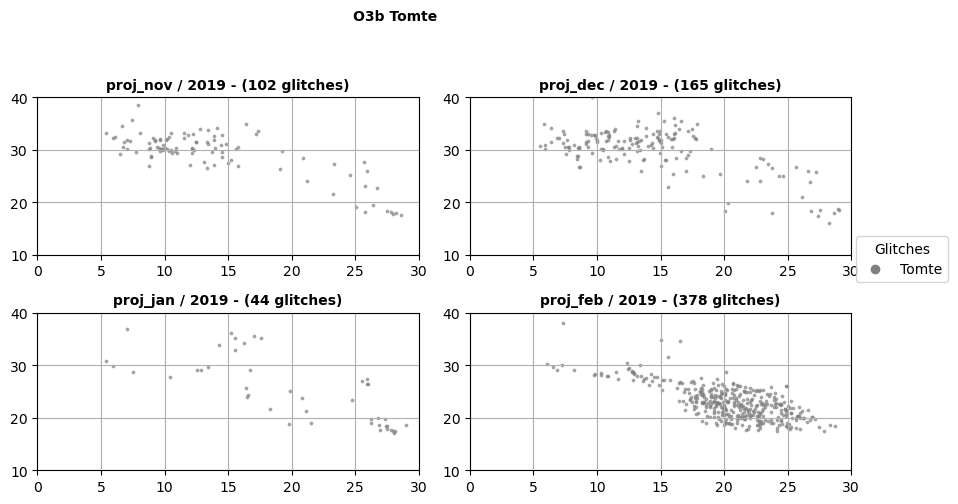

In [10]:
o3b_intervals = {
    'Nov': (1256655618, 1259247618),  # 01/Nov/2019 15:00 to 01/Dez/2019 15:00
    'Dec': (1259247618, 1261926018),  # 01/Dez/2019 15:00 to 01/Jan/2020 15:00
    'Jan': (1261926018, 1264604418),  # 01/Jan/2020 15:00 to 01/Fev/2020 15:00
    'Feb': (1264604418, 1267110018),  # 01/Fev/2020 15:00 to 01/Mar/2020 15:00
}
projs = gf.projections(repository, arq_name, dt, perp, o3b_intervals)

final_projs = {key: df[df['label'] == 'Tomte'] for key, df in projs.items()}
gf.plot_saz(final_projs, 'O3b Tomte', 'gray', xlim=(0, 30), ylim=(10, 40))